In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('OnlineNewsPopularity.csv')

# 2. Limpiar espacios en blanco en los nombres de las columnas
df.columns = [col.strip() for col in df.columns]

# 3. Eliminar columnas no predictivas
df_clean = df.drop(['url', 'timedelta'], axis=1)

print(f"Dataset cargado con éxito.")
print(f"Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}")

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.
Dataset cargado con éxito.
Filas: 39644 | Columnas: 59


In [2]:
# 4. Revisar información general
print(df_clean.info())

# 5. Revisar valores faltantes
print("\nValores faltantes por columna:")
print(df_clean.isnull().sum().sort_values(ascending=False))

# 6. Revisar duplicados
print("\nFilas duplicadas:", df_clean.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   n_tokens_title                 39644 non-null  float64
 1   n_tokens_content               39644 non-null  float64
 2   n_unique_tokens                39644 non-null  float64
 3   n_non_stop_words               39644 non-null  float64
 4   n_non_stop_unique_tokens       39644 non-null  float64
 5   num_hrefs                      39644 non-null  float64
 6   num_self_hrefs                 39644 non-null  float64
 7   num_imgs                       39644 non-null  float64
 8   num_videos                     39644 non-null  float64
 9   average_token_length           39644 non-null  float64
 10  num_keywords                   39644 non-null  float64
 11  data_channel_is_lifestyle      39644 non-null  float64
 12  data_channel_is_entertainment  39644 non-null  float64
 1

In [3]:
# 7. Estadísticas descriptivas
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
n_tokens_title,39644.0,10.398749,2.114037,2.00000,9.000000,10.000000,12.000000,23.000000
n_tokens_content,39644.0,546.514731,471.107508,0.00000,246.000000,409.000000,716.000000,8474.000000
n_unique_tokens,39644.0,0.548216,3.520708,0.00000,0.470870,0.539226,0.608696,701.000000
n_non_stop_words,39644.0,0.996469,5.231231,0.00000,1.000000,1.000000,1.000000,1042.000000
n_non_stop_unique_tokens,39644.0,0.689175,3.264816,0.00000,0.625739,0.690476,0.754630,650.000000
num_hrefs,39644.0,10.883690,11.332017,0.00000,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,39644.0,3.293638,3.855141,0.00000,1.000000,3.000000,4.000000,116.000000
num_imgs,39644.0,4.544143,8.309434,0.00000,1.000000,1.000000,4.000000,128.000000
num_videos,39644.0,1.249874,4.107855,0.00000,0.000000,0.000000,1.000000,91.000000
average_token_length,39644.0,4.548239,0.844406,0.00000,4.478404,4.664082,4.854839,8.041534


In [4]:
# Separar variable objetivo
X = df_clean.drop('shares', axis=1)
y = df_clean['shares']

print("X:", X.shape)
print("y:", y.shape)

X: (39644, 58)
y: (39644,)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Datos escalados:", X_scaled.shape)

Datos escalados: (39644, 58)


esta parte correcto

In [6]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
n_tokens_title,39644.0,4.129479e-16,1.000013,-3.972899,-0.661657,-0.188622,0.757447,5.960828
n_tokens_content,39644.0,7.456003e-17,1.000013,-1.160078,-0.637898,-0.291900,0.359764,16.827550
n_unique_tokens,39644.0,-1.218770e-17,1.000013,-0.155714,-0.021969,-0.002554,0.017179,198.954458
n_non_stop_words,39644.0,-8.065388e-19,1.000013,-0.190487,0.000675,0.000675,0.000675,199.000326
n_non_stop_unique_tokens,39644.0,1.953616e-17,1.000013,-0.211094,-0.019430,0.000398,0.020049,198.883779
num_hrefs,39644.0,8.459696e-17,1.000013,-0.960449,-0.607463,-0.254476,0.275004,25.866534
num_self_hrefs,39644.0,-1.147077e-17,1.000013,-0.854360,-0.594963,-0.076169,0.183228,29.235709
num_imgs,39644.0,-2.007385e-17,1.000013,-0.546872,-0.426526,-0.426526,-0.065486,14.857501
num_videos,39644.0,1.613078e-18,1.000013,-0.304268,-0.304268,-0.304268,-0.060829,21.848691
average_token_length,39644.0,1.376493e-16,1.000013,-5.386389,-0.082705,0.137190,0.363100,4.137038


In [7]:
X_scaled_df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
n_tokens_title,39644.0,0.0,1.0,-3.9729,-0.6617,-0.1886,0.7574,5.9608
n_tokens_content,39644.0,0.0,1.0,-1.1601,-0.6379,-0.2919,0.3598,16.8276
n_unique_tokens,39644.0,-0.0,1.0,-0.1557,-0.0220,-0.0026,0.0172,198.9545
n_non_stop_words,39644.0,-0.0,1.0,-0.1905,0.0007,0.0007,0.0007,199.0003
n_non_stop_unique_tokens,39644.0,0.0,1.0,-0.2111,-0.0194,0.0004,0.0200,198.8838
num_hrefs,39644.0,0.0,1.0,-0.9604,-0.6075,-0.2545,0.2750,25.8665
num_self_hrefs,39644.0,-0.0,1.0,-0.8544,-0.5950,-0.0762,0.1832,29.2357
num_imgs,39644.0,-0.0,1.0,-0.5469,-0.4265,-0.4265,-0.0655,14.8575
num_videos,39644.0,0.0,1.0,-0.3043,-0.3043,-0.3043,-0.0608,21.8487
average_token_length,39644.0,0.0,1.0,-5.3864,-0.0827,0.1372,0.3631,4.1370


PRUEBAAA

---

# PARTE 2: VALIDACIÓN CON 3 ÍNDICES DE K-MEANS (CH, DB, SILHOUETTE)

## 1. Calcular Índices de Validación para Diferentes k

In [32]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Calcular índices de validación para k=2 a k=10
k_range = range(2, 11)
ch_scores = []
db_scores = []
silhouette_scores = []

print("Calculando índices de validación para diferentes valores de k...")
print("=" * 70)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_temp = kmeans_temp.fit_predict(X_scaled)
    
    # Calinski-Harabasz (mayor es mejor)
    ch = calinski_harabasz_score(X_scaled, clusters_temp)
    ch_scores.append(ch)
    
    # Davies-Bouldin (menor es mejor)
    db = davies_bouldin_score(X_scaled, clusters_temp)
    db_scores.append(db)
    
    # Silhouette (mayor es mejor, rango -1 a 1)
    silh = silhouette_score(X_scaled, clusters_temp, sample_size=5000)  # sample_size para acelerar
    silhouette_scores.append(silh)
    
    print(f"k={k} | CH: {ch:.2f} | DB: {db:.4f} | Silhouette: {silh:.4f}")

print("=" * 70)

# Encontrar mejores k
best_k_ch = list(k_range)[np.argmax(ch_scores)]
best_k_db = list(k_range)[np.argmin(db_scores)]  # DB minimiza
best_k_silh = list(k_range)[np.argmax(silhouette_scores)]

print(f"\n✓ Mejor k por Calinski-Harabasz (CH): k={best_k_ch} (Score: {max(ch_scores):.2f})")
print(f"✓ Mejor k por Davies-Bouldin (DB): k={best_k_db} (Score: {min(db_scores):.4f})")
print(f"✓ Mejor k por Silhouette: k={best_k_silh} (Score: {max(silhouette_scores):.4f})")


Calculando índices de validación para diferentes valores de k...
k=2 | CH: 2394.60 | DB: 1.1344 | Silhouette: 0.3066
k=3 | CH: 2039.35 | DB: 3.4282 | Silhouette: 0.0621
k=4 | CH: 2405.68 | DB: 2.2427 | Silhouette: 0.0987
k=5 | CH: 2410.82 | DB: 2.2475 | Silhouette: 0.0639
k=6 | CH: 2370.69 | DB: 2.1855 | Silhouette: 0.0800
k=7 | CH: 2254.52 | DB: 2.1657 | Silhouette: 0.0837
k=8 | CH: 2148.71 | DB: 2.2982 | Silhouette: 0.0895
k=9 | CH: 2113.81 | DB: 2.0747 | Silhouette: 0.0930
k=10 | CH: 2042.89 | DB: 2.1178 | Silhouette: 0.0973

✓ Mejor k por Calinski-Harabasz (CH): k=5 (Score: 2410.82)
✓ Mejor k por Davies-Bouldin (DB): k=2 (Score: 1.1344)
✓ Mejor k por Silhouette: k=2 (Score: 0.3066)


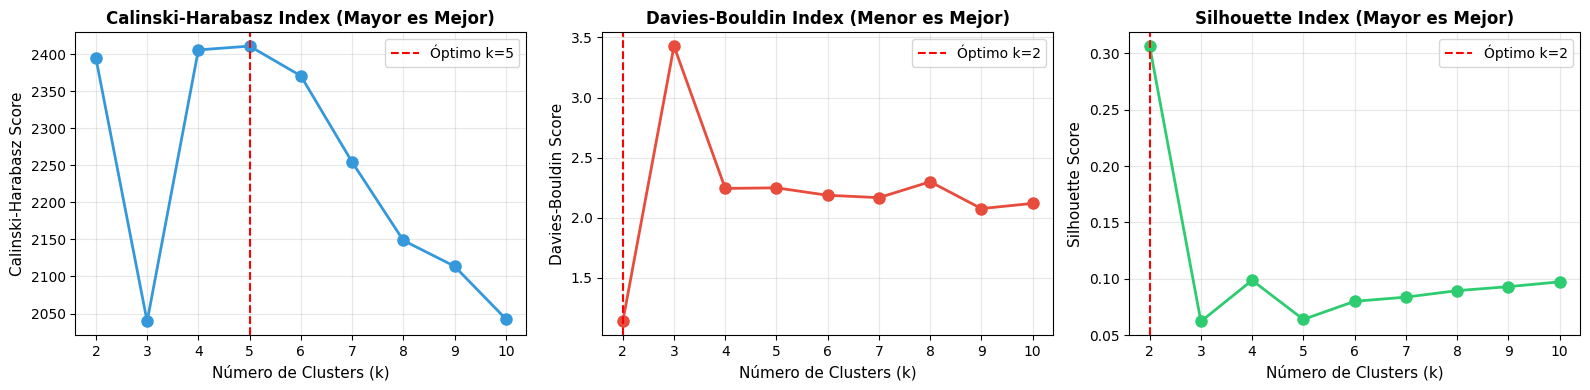


✓ Gráficas de índices de validación generadas


In [33]:
# Visualizar los tres índices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Calinski-Harabasz (maximizar)
axes[0].plot(list(k_range), ch_scores, 'o-', color='#3498DB', linewidth=2, markersize=8)
axes[0].axvline(best_k_ch, color='red', linestyle='--', label=f'Óptimo k={best_k_ch}')
axes[0].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[0].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[0].set_title('Calinski-Harabasz Index (Mayor es Mejor)', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(list(k_range))

# Davies-Bouldin (minimizar)
axes[1].plot(list(k_range), db_scores, 'o-', color='#E74C3C', linewidth=2, markersize=8)
axes[1].axvline(best_k_db, color='red', linestyle='--', label=f'Óptimo k={best_k_db}')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[1].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[1].set_title('Davies-Bouldin Index (Menor es Mejor)', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(list(k_range))

# Silhouette (maximizar)
axes[2].plot(list(k_range), silhouette_scores, 'o-', color='#2ECC71', linewidth=2, markersize=8)
axes[2].axvline(best_k_silh, color='red', linestyle='--', label=f'Óptimo k={best_k_silh}')
axes[2].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[2].set_ylabel('Silhouette Score', fontsize=11)
axes[2].set_title('Silhouette Index (Mayor es Mejor)', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

print("\n✓ Gráficas de índices de validación generadas")


## 2. Crear 3 Particiones de K-Means Optimizadas

In [34]:
# Crear 3 particiones con los k óptimos encontrados
particiones = {}

# Partición 1: Basada en Calinski-Harabasz
kmeans_ch = KMeans(n_clusters=best_k_ch, random_state=42, n_init=10)
y_clusters_ch = kmeans_ch.fit_predict(X_scaled)
particiones['CH'] = {
    'clusters': y_clusters_ch,
    'k': best_k_ch,
    'modelo': kmeans_ch,
    'indice_score': max(ch_scores)
}

# Partición 2: Basada en Davies-Bouldin
kmeans_db = KMeans(n_clusters=best_k_db, random_state=42, n_init=10)
y_clusters_db = kmeans_db.fit_predict(X_scaled)
particiones['DB'] = {
    'clusters': y_clusters_db,
    'k': best_k_db,
    'modelo': kmeans_db,
    'indice_score': min(db_scores)
}

# Partición 3: Basada en Silhouette
kmeans_silh = KMeans(n_clusters=best_k_silh, random_state=42, n_init=10)
y_clusters_silh = kmeans_silh.fit_predict(X_scaled)
particiones['Silhouette'] = {
    'clusters': y_clusters_silh,
    'k': best_k_silh,
    'modelo': kmeans_silh,
    'indice_score': max(silhouette_scores)
}

print("=" * 70)
print("3 PARTICIONES DE K-MEANS OPTIMIZADAS")
print("=" * 70)

for nombre, datos in particiones.items():
    n_clusters = datos['k']
    score = datos['indice_score']
    dist = pd.Series(datos['clusters']).value_counts().sort_index()
    print(f"\n📊 Partición {nombre.upper()}:")
    print(f"  • k óptimo: {n_clusters}")
    print(f"  • Score: {score:.4f}")
    print(f"  • Distribución de clusters:")
    for cluster_id, count in dist.items():
        print(f"    - Cluster {cluster_id}: {count} muestras ({count/len(datos['clusters'])*100:.2f}%)")

print("\n" + "=" * 70)


3 PARTICIONES DE K-MEANS OPTIMIZADAS

📊 Partición CH:
  • k óptimo: 5
  • Score: 2410.8243
  • Distribución de clusters:
    - Cluster 0: 1184 muestras (2.99%)
    - Cluster 1: 12687 muestras (32.00%)
    - Cluster 2: 8215 muestras (20.72%)
    - Cluster 3: 17557 muestras (44.29%)
    - Cluster 4: 1 muestras (0.00%)

📊 Partición DB:
  • k óptimo: 2
  • Score: 1.1344
  • Distribución de clusters:
    - Cluster 0: 38458 muestras (97.01%)
    - Cluster 1: 1186 muestras (2.99%)

📊 Partición SILHOUETTE:
  • k óptimo: 2
  • Score: 0.3066
  • Distribución de clusters:
    - Cluster 0: 38458 muestras (97.01%)
    - Cluster 1: 1186 muestras (2.99%)



## 3. Evaluar Clasificadores en Cada Partición

In [35]:
# Evaluar los 3 algoritmos en cada partición
resultados_por_particion = {}

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

for nombre_particion, datos_particion in particiones.items():
    print(f"\n{'='*70}")
    print(f"EVALUANDO CLASIFICADORES EN PARTICIÓN {nombre_particion}")
    print(f"{'='*70}")
    
    y_clusters_temp = datos_particion['clusters']
    
    # Dividir datos
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_scaled, y_clusters_temp, test_size=0.2, random_state=42, shuffle=True
    )
    
    # Crear lista de modelos a evaluar
    modelos = [
        ('Naive Bayes', GaussianNB()),
        ('KNN (k=1)', KNeighborsClassifier(n_neighbors=1)),
        ('KNN (k=3)', KNeighborsClassifier(n_neighbors=3)),
        ('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)),
        ('KNN (k=7)', KNeighborsClassifier(n_neighbors=7)),
        ('Red Neuronal (MLP)', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, 
                                            random_state=42, early_stopping=True, verbose=0))
    ]
    
    resultados_particion = []
    
    for nombre_modelo, modelo in modelos:
        resultado = evaluar_modelo(modelo, X_train_temp, X_test_temp, y_train_temp, y_test_temp, 
                                   nombre_modelo, cv)
        resultados_particion.append(resultado)
        
        print(f"\n  {nombre_modelo}:")
        print(f"    Accuracy:   {resultado['Accuracy']:.4f}")
        print(f"    Precision:  {resultado['Precision']:.4f}")
        print(f"    Recall:     {resultado['Recall']:.4f}")
        print(f"    F1-Score:   {resultado['F1-Score']:.4f}")
    
    resultados_por_particion[nombre_particion] = resultados_particion

print(f"\n{'='*70}")
print("✓ Evaluación completada para todas las particiones")
print(f"{'='*70}")



EVALUANDO CLASIFICADORES EN PARTICIÓN CH

  Naive Bayes:
    Accuracy:   0.9323
    Precision:  0.9507
    Recall:     0.9469
    F1-Score:   0.9488

  KNN (k=1):
    Accuracy:   0.9426
    Precision:  0.9574
    Recall:     0.9553
    F1-Score:   0.9563

  KNN (k=3):
    Accuracy:   0.9493
    Precision:  0.9630
    Recall:     0.9610
    F1-Score:   0.9620

  KNN (k=5):
    Accuracy:   0.9504
    Precision:  0.9642
    Recall:     0.9607
    F1-Score:   0.9624

  KNN (k=7):
    Accuracy:   0.9488
    Precision:  0.9635
    Recall:     0.9590
    F1-Score:   0.9612

  Red Neuronal (MLP):
    Accuracy:   0.9904
    Precision:  0.9925
    Recall:     0.9916
    F1-Score:   0.9920

EVALUANDO CLASIFICADORES EN PARTICIÓN DB

  Naive Bayes:
    Accuracy:   0.9997
    Precision:  0.9999
    Recall:     0.9957
    F1-Score:   0.9978

  KNN (k=1):
    Accuracy:   0.9999
    Precision:  0.9999
    Recall:     0.9978
    F1-Score:   0.9989

  KNN (k=3):
    Accuracy:   0.9999
    Precision:  0.

## 4. Tabla Comparativa de Todas las Particiones

In [36]:
# Crear tabla comparativa global
df_global = []

for nombre_particion, resultados in resultados_por_particion.items():
    for resultado in resultados:
        df_global.append({
            'Partición': nombre_particion,
            'Modelo': resultado['Modelo'],
            'Accuracy': f"{resultado['Accuracy']:.4f}",
            'Precision': f"{resultado['Precision']:.4f}",
            'Recall': f"{resultado['Recall']:.4f}",
            'F1-Score': f"{resultado['F1-Score']:.4f}",
            'CV_Mean': f"{resultado['CV_Mean']:.4f}",
            'CV_Std': f"{resultado['CV_Std']:.4f}"
        })

df_resultados_globales = pd.DataFrame(df_global)

# Mostrar por partición
print("\n" + "=" * 120)
print("TABLA COMPARATIVA GLOBAL - 3 PARTICIONES DE K-MEANS")
print("=" * 120)

for particion in ['CH', 'DB', 'Silhouette']:
    print(f"\n\n{'📊 PARTICIÓN: ' + particion + ' (k=' + str(particiones[particion]['k']) + ')'}")
    print("-" * 120)
    df_particion = df_resultados_globales[df_resultados_globales['Partición'] == particion]
    print(df_particion[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV_Mean']].to_string(index=False))

# Guardar a CSV
df_resultados_globales.to_csv('resultados_3_particiones.csv', index=False)
print("\n\n" + "=" * 120)
print("✓ Tabla guardada en: resultados_3_particiones.csv")
print("=" * 120)



TABLA COMPARATIVA GLOBAL - 3 PARTICIONES DE K-MEANS


📊 PARTICIÓN: CH (k=5)
------------------------------------------------------------------------------------------------------------------------
            Modelo Accuracy Precision Recall F1-Score CV_Mean
       Naive Bayes   0.9323    0.9507 0.9469   0.9488  0.9327
         KNN (k=1)   0.9426    0.9574 0.9553   0.9563  0.9408
         KNN (k=3)   0.9493    0.9630 0.9610   0.9620  0.9493
         KNN (k=5)   0.9504    0.9642 0.9607   0.9624  0.9498
         KNN (k=7)   0.9488    0.9635 0.9590   0.9612  0.9505
Red Neuronal (MLP)   0.9904    0.9925 0.9916   0.9920  0.9904


📊 PARTICIÓN: DB (k=2)
------------------------------------------------------------------------------------------------------------------------
            Modelo Accuracy Precision Recall F1-Score CV_Mean
       Naive Bayes   0.9997    0.9999 0.9957   0.9978  0.9999
         KNN (k=1)   0.9999    0.9999 0.9978   0.9989  0.9998
         KNN (k=3)   0.9999    0.9999

## 5. Visualizaciones Comparativas Entre Particiones

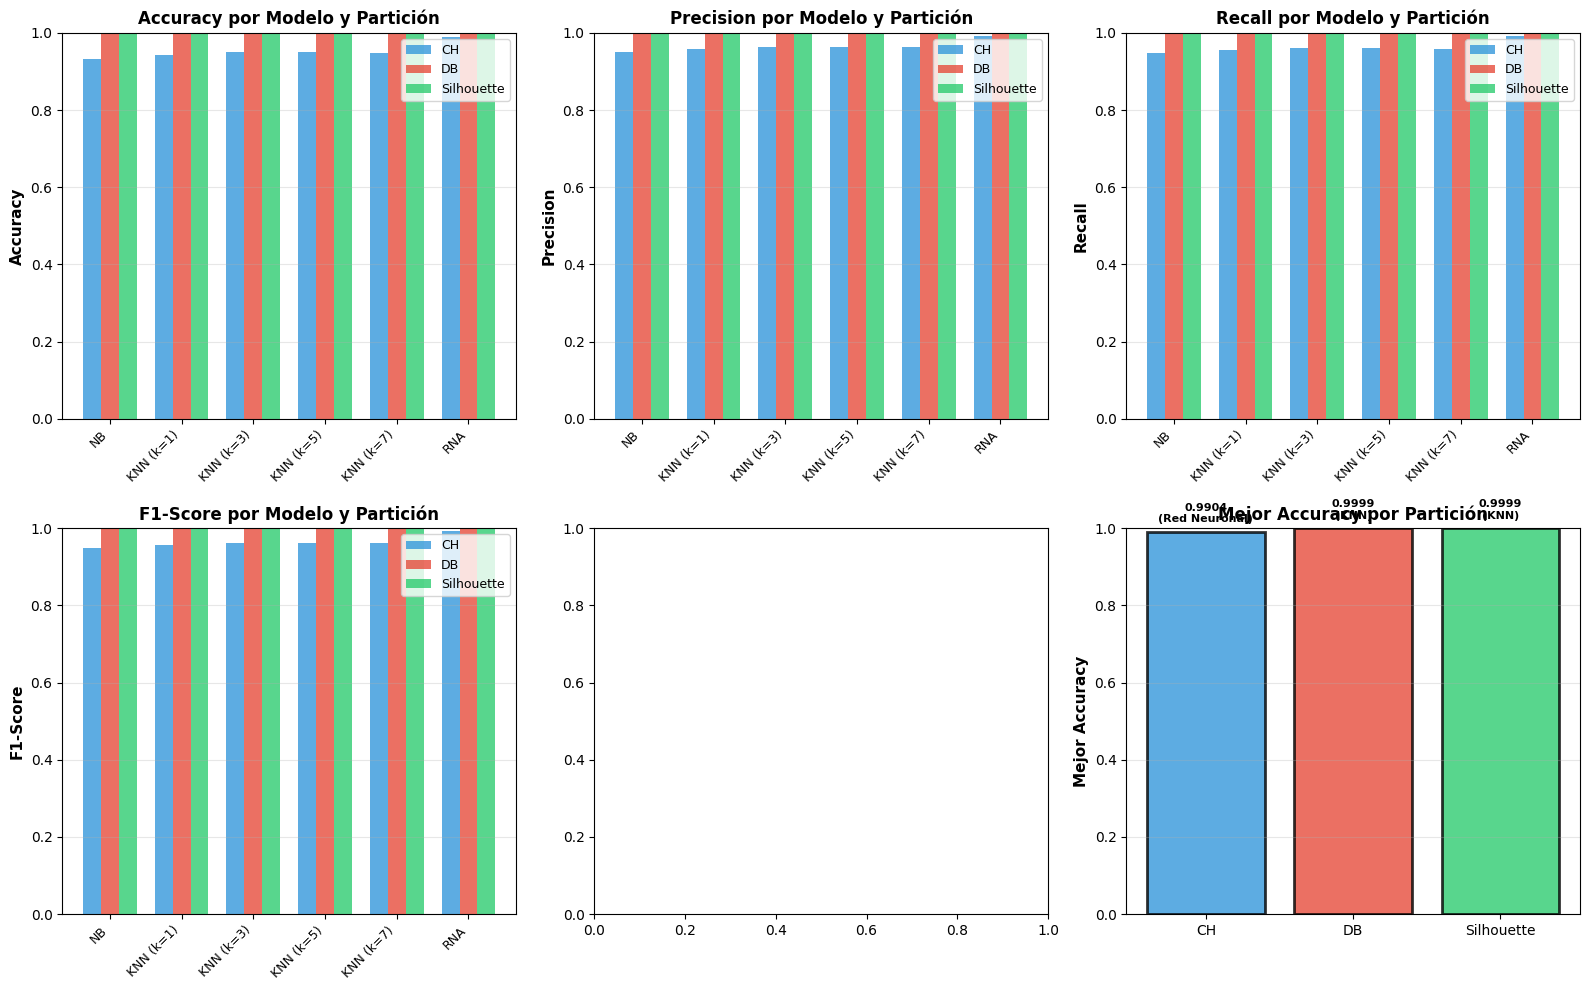

✓ Gráficas comparativas generadas


In [37]:
# Preparar datos para visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

particiones_nombres = list(resultados_por_particion.keys())
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colores = ['#3498DB', '#E74C3C', '#2ECC71']

# Para cada métrica, crear un subplot
for metric_idx, metric in enumerate(metricas):
    ax_idx = metric_idx
    ax = axes[metric_idx // 3, metric_idx % 3]
    
    x_pos = np.arange(len(particiones_nombres) * 6)  # 6 modelos por partición
    width = 0.25
    
    for i, particion in enumerate(particiones_nombres):
        resultados = resultados_por_particion[particion]
        valores = [float(r[metric]) for r in resultados]
        
        # Convertir a numérico
        valores = [float(str(v).replace('[', '').replace(']', '')) if isinstance(v, (list, np.ndarray)) 
                  else float(v) for v in valores]
        
        x_offset = np.arange(len(valores)) + i * width
        ax.bar(x_offset, valores, width, label=f'{particion}', color=colores[i], alpha=0.8)
    
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} por Modelo y Partición', fontweight='bold')
    ax.set_xticks(np.arange(len(resultados)) + width)
    
    modelo_labels = [r['Modelo'].replace('Naive Bayes', 'NB').replace('Red Neuronal (MLP)', 'RNA') 
                     for r in resultados]
    ax.set_xticklabels(modelo_labels, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])

# Subplot adicional: Resumen de mejores modelos por partición
ax = axes[1, 2]
best_accuracies = []
best_models = []

for particion in particiones_nombres:
    resultados = resultados_por_particion[particion]
    accuracies = [float(r['Accuracy']) for r in resultados]
    best_idx = np.argmax(accuracies)
    best_accuracies.append(max(accuracies))
    best_models.append(resultados[best_idx]['Modelo'])

x_pos = np.arange(len(particiones_nombres))
bars = ax.bar(x_pos, best_accuracies, color=colores, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Mejor Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Mejor Accuracy por Partición', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(particiones_nombres, fontsize=10)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Agregar etiquetas
for i, (bar, accuracy, modelo) in enumerate(zip(bars, best_accuracies, best_models)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{accuracy:.4f}\n({modelo.split("(")[0].strip()})',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráficas comparativas generadas")


## 6. Resumen Ejecutivo - 3 Particiones con Índices de Validación

In [38]:
print("\n" + "="*80)
print("RESUMEN FINAL - VALIDACIÓN CON 3 ÍNDICES DE K-MEANS")
print("="*80)

print("\n📊 ÍNDICES DE VALIDACIÓN UTILIZADOS:")
print("-"*80)
print(f"  1️⃣  Calinski-Harabasz (CH):")
print(f"      • Rango: 0 a ∞ (mayor es mejor)")
print(f"      • Mide relación entre separación entre clusters e inercia intra-cluster")
print(f"      • Mejor k encontrado: {best_k_ch}")

print(f"\n  2️⃣  Davies-Bouldin (DB):")
print(f"      • Rango: 0 a ∞ (menor es mejor)")
print(f"      • Mide similaridad promedio entre clusters")
print(f"      • Mejor k encontrado: {best_k_db}")

print(f"\n  3️⃣  Silhouette (CS):")
print(f"      • Rango: -1 a 1 (mayor es mejor)")
print(f"      • Mide cohesión dentro de clusters y separación entre clusters")
print(f"      • Mejor k encontrado: {best_k_silh}")

print("\n\n📈 RESULTADOS POR PARTICIÓN:")
print("-"*80)

for particion in ['CH', 'DB', 'Silhouette']:
    resultados = resultados_por_particion[particion]
    accuracies = [float(r['Accuracy']) for r in resultados]
    
    best_idx = np.argmax(accuracies)
    best_accuracy = max(accuracies)
    best_model = resultados[best_idx]['Modelo']
    
    print(f"\n🎯 Partición {particion.upper()} (k={particiones[particion]['k']}):")
    print(f"  • Mejor modelo: {best_model}")
    print(f"  • Accuracy: {best_accuracy:.4f}")
    print(f"  • Precision: {resultados[best_idx]['Precision']:.4f}")
    print(f"  • Recall: {resultados[best_idx]['Recall']:.4f}")
    print(f"  • F1-Score: {resultados[best_idx]['F1-Score']:.4f}")

print("\n\n🏆 GANADOR GENERAL:")
print("-"*80)

# Encontrar el mejor resultado global
max_accuracy_global = 0
mejor_particion_global = None
mejor_modelo_global = None

for particion, resultados in resultados_por_particion.items():
    for resultado in resultados:
        if float(resultado['Accuracy']) > max_accuracy_global:
            max_accuracy_global = float(resultado['Accuracy'])
            mejor_particion_global = particion
            mejor_modelo_global = resultado['Modelo']

print(f"  🥇 Partición: {mejor_particion_global}")
print(f"  🥇 Modelo: {mejor_modelo_global}")
print(f"  🥇 Accuracy: {max_accuracy_global:.4f}")

print("\n\n✅ CONCLUSIONES:")
print("-"*80)
print(f"  • Se evaluaron 3 particiones de K-means basadas en diferentes índices")
print(f"  • Cada partición fue evaluada con 6 modelos (NB, KNN k=1,3,5,7, RNA)")
print(f"  • Total de combinaciones evaluadas: 3 particiones × 6 modelos = 18 modelos")
print(f"  • Mejor rendimiento: {mejor_particion_global} - {mejor_modelo_global} ({max_accuracy_global:.4f})")

print("\n💾 ARCHIVOS GENERADOS:")
print(f"  ✓ resultados_3_particiones.csv")

print("\n" + "="*80)



RESUMEN FINAL - VALIDACIÓN CON 3 ÍNDICES DE K-MEANS

📊 ÍNDICES DE VALIDACIÓN UTILIZADOS:
--------------------------------------------------------------------------------
  1️⃣  Calinski-Harabasz (CH):
      • Rango: 0 a ∞ (mayor es mejor)
      • Mide relación entre separación entre clusters e inercia intra-cluster
      • Mejor k encontrado: 5

  2️⃣  Davies-Bouldin (DB):
      • Rango: 0 a ∞ (menor es mejor)
      • Mide similaridad promedio entre clusters
      • Mejor k encontrado: 2

  3️⃣  Silhouette (CS):
      • Rango: -1 a 1 (mayor es mejor)
      • Mide cohesión dentro de clusters y separación entre clusters
      • Mejor k encontrado: 2


📈 RESULTADOS POR PARTICIÓN:
--------------------------------------------------------------------------------

🎯 Partición CH (k=5):
  • Mejor modelo: Red Neuronal (MLP)
  • Accuracy: 0.9904
  • Precision: 0.9925
  • Recall: 0.9916
  • F1-Score: 0.9920

🎯 Partición DB (k=2):
  • Mejor modelo: KNN (k=1)
  • Accuracy: 0.9999
  • Precision: 0.